# Baseline: hierarkisk multi-head CNN (nivå 1 + nivå 2)

Denne notebooken bygger videre på de ferdige `train/val/test`-splittene og trener en enkel baseline-modell:

- **Nivå 1**: `Tesla` vs `Other` (binary)
- **Nivå 2**: Tesla-underklasser (sparse categorical), **maskert for `Other`** med `sample_weight`.

## Forutsetninger
- Du har `datasplitt/train.csv`, `val.csv`, `test.csv`.
- CSV-ene inneholder minst: `image`, `model`, `lighting`.
- `image` er relativ sti under `IMG_ROOT` (datasett-roten). I denne repo-strukturen settes IMG_ROOT = PROJECT_ROOT / "datasett_src".

## Steg i denne notebooken
- Leser datasplitt (train/val/test) fra `datasplitt/`.
- Forbereder labels og sample weights for hierarkisk trening.
- Bygger `tf.data` pipeline med robust bildekoding.
- Trener en enkel baseline-modell med to output-hoder (nivå 1 og nivå 2).
- Evaluerer totalt og per lyskategori.

### Imports og grunnkonfigurasjon

Importerer nødvendige biblioteker og setter grunnparametre (seed, bildeformat, batch-størrelse).

In [1]:
# 0) Imports
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
tf.config.optimizer.set_jit(False)  # disable XLA autoclustering

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)

print("TF:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))


TF: 2.15.1
GPU: []


### Les datasplitt (train/val/test)

Splittene (`train`, `val`, `test`) leses fra faste CSV-filer slik at alle eksperimenter evalueres på identiske delsett.

CSV-ene forventes å inneholde minst:
- `image` (relativ filsti/filnavn)
- `model` (klasse/labelgrunnlag)
- `lighting` (Light/Medium/Dark)

In [2]:
# 1) Les inn datasplitt og vis info

# Konstanter og prosjektstruktur
SEED = 42
IMG_SIZE = (300, 300)   # Modellens inputstørrelse
SHORT_SIDE = 300      # Vi resizer slik at korteste side blir 300 før center-crop
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

tf.random.set_seed(SEED)
np.random.seed(SEED)

# Finn prosjektrot robust (forutsetter at mappen 'annotations' finnes)
cwd = Path.cwd().resolve()
PROJECT_ROOT = next(
    p for p in [cwd, *cwd.parents]
    if (p / "annotations" / "combined_clean_strict.csv").exists()
)

SPLIT_DIR = PROJECT_ROOT / "datasplitt"
TRAIN_CSV = SPLIT_DIR / "train.csv"
VAL_CSV   = SPLIT_DIR / "val.csv"
TEST_CSV  = SPLIT_DIR / "test.csv"

if not (TRAIN_CSV.exists() and VAL_CSV.exists() and TEST_CSV.exists()):
    raise FileNotFoundError("Finner ikke train/val/test i datasplitt/.")

train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("SPLIT_DIR:", SPLIT_DIR)
print("rows train/val/test:", len(train_df), len(val_df), len(test_df))
print("columns:", train_df.columns.tolist())
display(train_df.head())


PROJECT_ROOT: C:\Users\andre\DAT191\visual-vehicle-recognition-varying-lighting-conditions
SPLIT_DIR: C:\Users\andre\DAT191\visual-vehicle-recognition-varying-lighting-conditions\datasplitt
rows train/val/test: 3033 650 651
columns: ['color', 'image', 'lighting', 'model', 'source', 'year', 'lvl1', 'lvl2', 'strat_key']


,color,image,lighting,model,source,year,lvl1,lvl2,strat_key
0,Red,Eksternt/Tesla/daylight/Kaggle/S/images - 2023...,Light,S 2012–2015,external,2012–2015,Tesla,S 2012–2015,Tesla|S 2012–2015|Light
1,Light gray/Silver,Eksternt/non-tesla/daylight/0814_01435.jpg,Light,Other car,external,NaN,Other,NaN,Other|NA|Light
2,Light gray/Silver,Eksternt/non-tesla/daylight/0689_04020.jpg,Light,Other car,external,NaN,Other,NaN,Other|NA|Light
3,Light gray/Silver,Egenprodusert/Tesla/low-light/IMG_1424.jpg,Medium,3 2017–2023,internal,2017–2023,Tesla,3 2017–2023,Tesla|3 2017–2023|Medium
4,Black/Dark gray,Egenprodusert/Tesla/daylight/%~n1-495.jpg,Light,Y 2025-nå,internal,2025-nå,Tesla,Y 2025-nå,Tesla|Y 2025-nå|Light


### Angi bildemappe (IMG_ROOT)

Setter rotmappen der bildefilene ligger. Stiene i `image`-kolonnen i CSV er **relative** til denne mappen.

In [3]:
# 2) Last split CSV-er

# Viktig: `IMG_ROOT / <image>` må peke til en faktisk fil på disk.
# Eksempelstier i CSV kan være som: Eksternt/Tesla/... eller Egenprodusert/...
# 2) Sett IMG_ROOT (datasett-roten som 'image' er relativ til)
IMG_ROOT = PROJECT_ROOT / "datasett_src"
print("IMG_ROOT:", IMG_ROOT)
print("IMG_ROOT exists:", IMG_ROOT.exists())

if not IMG_ROOT.exists():
    raise FileNotFoundError(f"Finner ikke IMG_ROOT: {IMG_ROOT}")

train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

display(train_df.head())
print("train/val/test:", len(train_df), len(val_df), len(test_df))
print("columns:", train_df.columns.tolist())

IMG_ROOT: C:\Users\andre\DAT191\visual-vehicle-recognition-varying-lighting-conditions\datasett_src
IMG_ROOT exists: True


,color,image,lighting,model,source,year,lvl1,lvl2,strat_key
0,Red,Eksternt/Tesla/daylight/Kaggle/S/images - 2023...,Light,S 2012–2015,external,2012–2015,Tesla,S 2012–2015,Tesla|S 2012–2015|Light
1,Light gray/Silver,Eksternt/non-tesla/daylight/0814_01435.jpg,Light,Other car,external,NaN,Other,NaN,Other|NA|Light
2,Light gray/Silver,Eksternt/non-tesla/daylight/0689_04020.jpg,Light,Other car,external,NaN,Other,NaN,Other|NA|Light
3,Light gray/Silver,Egenprodusert/Tesla/low-light/IMG_1424.jpg,Medium,3 2017–2023,internal,2017–2023,Tesla,3 2017–2023,Tesla|3 2017–2023|Medium
4,Black/Dark gray,Egenprodusert/Tesla/daylight/%~n1-495.jpg,Light,Y 2025-nå,internal,2025-nå,Tesla,Y 2025-nå,Tesla|Y 2025-nå|Light


train/val/test: 3033 650 651
columns: ['color', 'image', 'lighting', 'model', 'source', 'year', 'lvl1', 'lvl2', 'strat_key']


In [4]:
# 2b) Statistikk: hvor mange bilder er kvadratiske vs avlange?
# Dette hjelper dere å dokumentere hvor mange bilder som blir påvirket av center-crop.
import os
import numpy as np
import pandas as pd
import tensorflow as tf

def _get_hw_tf(path: tf.Tensor):
    """Returnerer (H, W) effektivt. JPEG bruker extract_jpeg_shape (leser header)."""
    lower = tf.strings.lower(path)
    file_bytes = tf.io.read_file(path)

    is_png = tf.strings.regex_full_match(lower, ".*\\.png")
    is_jpg = tf.strings.regex_full_match(lower, ".*\\.(jpg|jpeg)")

    def jpg_branch():
        s = tf.image.extract_jpeg_shape(file_bytes)  # [H, W, C]
        return s[0], s[1]

    def png_branch():
        img = tf.image.decode_png(file_bytes, channels=3)
        s = tf.shape(img)
        return s[0], s[1]

    def other_branch():
        img = tf.image.decode_image(file_bytes, channels=3, expand_animations=False)
        s = tf.shape(img)
        return s[0], s[1]

    h, w = tf.case([(is_jpg, jpg_branch), (is_png, png_branch)],
                   default=other_branch, exclusive=True)
    return tf.cast(h, tf.int32), tf.cast(w, tf.int32)

def aspect_stats(df: pd.DataFrame, name: str) -> dict:
    rel = df["image"].astype(str).tolist()
    abs_paths = [str(IMG_ROOT / p) for p in rel]

    exists = [p for p in abs_paths if os.path.exists(p)]
    missing = len(abs_paths) - len(exists)

    ds = (tf.data.Dataset.from_tensor_slices(exists)
          .map(_get_hw_tf, num_parallel_calls=AUTOTUNE)
          .prefetch(AUTOTUNE))

    n = square = portrait = landscape = 0
    crop_fracs = []

    for h, w in ds.as_numpy_iterator():
        n += 1
        if h == w:
            square += 1
            crop_fracs.append(0.0)
            continue
        if h > w:
            portrait += 1
        else:
            landscape += 1

        r = max(h, w) / min(h, w)  # aspect ratio >= 1
        # Etter resize (korteste side -> 300) og center-crop 300x300,
        # blir andel av "langside" som kuttes bort omtrent (r-1)/r.
        crop_fracs.append((r - 1.0) / r)

    if n == 0:
        return {"split": name, "total_i_csv": len(abs_paths), "missing_files": missing, "checked": 0}

    cf = np.array(crop_fracs, dtype=float)
    return {
        "split": name,
        "total_i_csv": len(abs_paths),
        "missing_files": missing,
        "checked": n,
        "square": square,
        "non_square": n - square,
        "portrait": portrait,
        "landscape": landscape,
        "avg_crop_%": float(cf.mean() * 100.0),
        "p50_crop_%": float(np.quantile(cf, 0.50) * 100.0),
        "p90_crop_%": float(np.quantile(cf, 0.90) * 100.0),
        "max_crop_%": float(cf.max() * 100.0),
    }

stats = [
    aspect_stats(train_df, "train"),
    aspect_stats(val_df, "val"),
    aspect_stats(test_df, "test"),
    aspect_stats(pd.concat([train_df, val_df, test_df], ignore_index=True), "ALL"),
]

pd.DataFrame(stats)


,split,total_i_csv,missing_files,checked,square,non_square,portrait,landscape,avg_crop_%,p50_crop_%,p90_crop_%,max_crop_%
0,train,3033,0,3033,962,2071,452,1619,21.108750,25.0,40.031250,75.055679
1,val,650,0,650,217,433,85,348,20.612412,25.0,41.637484,63.000000
2,test,651,0,651,205,446,99,347,21.324950,25.0,42.857143,74.276779
3,ALL,4334,0,4334,1384,2950,636,2314,21.066786,25.0,41.073542,75.055679


### Valider hierarkiske kolonner

HHer verifiseres (og eventuelt konstrueres) de hierarkiske kolonnene som brukes videre i pipeline:

- `lvl1`: Tesla vs Other  
- `lvl2`: Tesla-underklasse (for Other brukes en nøytral plassholder)

Valideringen sikrer også at nødvendige basis-kolonner finnes før videre behandling.

In [5]:
# 3) Bygg/valider hierarki-kolonner (idempotent: ok om de allerede finnes)
def ensure_hierarchy(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    for c in ["image", "model", "lighting"]:
        if c not in out.columns:
            raise KeyError(f"Mangler kolonne '{c}' i split-CSV. Fant: {out.columns.tolist()}")

    out["model"] = out["model"].astype("string")
    out["lighting"] = out["lighting"].astype("string")

    # lvl1: Tesla vs Other
    if "lvl1" not in out.columns:
        is_other = out["model"].str.strip().str.lower().eq("other")
        out["lvl1"] = np.where(is_other, "Other", "Tesla")

    # lvl2: Tesla-underklasse (bruk 'model' direkte, siden prepare_dataset.py periodiserer)
    if "lvl2" not in out.columns:
        out["lvl2"] = out["model"].where(out["lvl1"].eq("Tesla"), "NA")

    # sample weight for lvl2 (kun Tesla)
    if "w_lvl2" not in out.columns:
        out["w_lvl2"] = (out["lvl1"].eq("Tesla")).astype(np.float32)

    return out

train_df = ensure_hierarchy(train_df)
val_df   = ensure_hierarchy(val_df)
test_df  = ensure_hierarchy(test_df)

print("lvl1 counts (train):\n", train_df["lvl1"].value_counts())
print("\nlvl2 counts (train):\n", train_df["lvl2"].value_counts().head(20))
print("\nlighting counts (train):\n", train_df["lighting"].value_counts())

lvl1 counts (train):
 lvl1
Tesla    1596
Other    1437
Name: count, dtype: int64

lvl2 counts (train):
 lvl2
Y 2020–2024    600
3 2017–2023    241
Y 2025-nå      227
X              185
3 2024–nå      172
S 2016–nå       95
S 2012–2015     76
Name: count, dtype: int64

lighting counts (train):
 lighting
Light     2066
Dark       492
Medium     475
Name: count, dtype: Int64


### Label-space, encoding og maskering (y_lvl1/y_lvl2 + w_lvl2)

Denne blokken klargjør labels og vekter for trening med en hierarkisk multi-head modell.

1. **Label-space defineres**
   - `lvl1` mappes fast: Other → 0, Tesla → 1
   - `lvl2`-klassene bestemmes fra treningssettet (kun Tesla-rader) og mappes til id-er 0..K−1

2. **Heltalls-targets konstrueres**
   - `y_lvl1` opprettes fra `lvl1`
   - `y_lvl2` opprettes fra `lvl2` for Tesla-rader; Other får en dummyverdi (0)

3. **Maskering av lvl2-loss**
   - `w_lvl2` brukes som sample weight slik at lvl2-loss ignoreres for Other (`w_lvl2 = 0`)
   - `w_lvl1` settes til 1 for alle rader

In [6]:

# lvl1: Other=0, Tesla=1 (fast)
lvl1_map = {"Other": 0, "Tesla": 1}

# lvl2: kun Tesla-klasser (fra train)
lvl2_classes = sorted(train_df.loc[train_df["lvl1"].eq("Tesla"), "lvl2"].astype("string").unique().tolist())
lvl2_to_id = {c: i for i, c in enumerate(lvl2_classes)}
num_lvl2 = len(lvl2_classes)

print("Antall lvl2-klasser:", num_lvl2)
print("Eksempel lvl2-klasser:", lvl2_classes[:10])

def add_encoded(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["y_lvl1"] = out["lvl1"].map(lvl1_map).astype(np.int32)

    # dummy 0 for Other (maskeres bort med w_lvl2=0)
    y2 = np.zeros(len(out), dtype=np.int32)
    tesla_mask = out["lvl1"].eq("Tesla").to_numpy()
    y2[tesla_mask] = out.loc[tesla_mask, "lvl2"].map(lvl2_to_id).astype(np.int32).to_numpy()
    out["y_lvl2"] = y2

    out["w_lvl1"] = 1.0
    out["w_lvl2"] = out["w_lvl2"].astype(np.float32)
    return out

train_df = add_encoded(train_df)
val_df   = add_encoded(val_df)
test_df  = add_encoded(test_df)

display(train_df[["image","lvl1","lvl2","lighting","y_lvl1","y_lvl2","w_lvl2"]].head())

Antall lvl2-klasser: 7
Eksempel lvl2-klasser: ['3 2017–2023', '3 2024–nå', 'S 2012–2015', 'S 2016–nå', 'X', 'Y 2020–2024', 'Y 2025-nå']


,image,lvl1,lvl2,lighting,y_lvl1,y_lvl2,w_lvl2
0,Eksternt/Tesla/daylight/Kaggle/S/images - 2023...,Tesla,S 2012–2015,Light,1,2,1.0
1,Eksternt/non-tesla/daylight/0814_01435.jpg,Other,NaN,Light,0,0,0.0
2,Eksternt/non-tesla/daylight/0689_04020.jpg,Other,NaN,Light,0,0,0.0
3,Egenprodusert/Tesla/low-light/IMG_1424.jpg,Tesla,3 2017–2023,Medium,1,0,1.0
4,Egenprodusert/Tesla/daylight/%~n1-495.jpg,Tesla,Y 2025-nå,Light,1,6,1.0


### Sanity check: verifisering av bilder

Før `tf.data`-pipen bygges, verifiseres det at filstiene faktisk peker på eksisterende bildefiler.  
Et lite utvalg fra treningssettet sjekkes for å avdekke feil i `IMG_ROOT`, relative paths eller mappestruktur tidlig.

In [7]:
sample_paths = [str(IMG_ROOT / p) for p in train_df["image"].astype(str).head(10)]
exists = [Path(p).exists() for p in sample_paths]
for p, e in zip(sample_paths, exists):
    print(e, p)

True C:\Users\andre\DAT191\visual-vehicle-recognition-varying-lighting-conditions\datasett_src\Eksternt\Tesla\daylight\Kaggle\S\images - 2023-08-30T035700.004.jpg
True C:\Users\andre\DAT191\visual-vehicle-recognition-varying-lighting-conditions\datasett_src\Eksternt\non-tesla\daylight\0814_01435.jpg
True C:\Users\andre\DAT191\visual-vehicle-recognition-varying-lighting-conditions\datasett_src\Eksternt\non-tesla\daylight\0689_04020.jpg
True C:\Users\andre\DAT191\visual-vehicle-recognition-varying-lighting-conditions\datasett_src\Egenprodusert\Tesla\low-light\IMG_1424.jpg
True C:\Users\andre\DAT191\visual-vehicle-recognition-varying-lighting-conditions\datasett_src\Egenprodusert\Tesla\daylight\%~n1-495.jpg
True C:\Users\andre\DAT191\visual-vehicle-recognition-varying-lighting-conditions\datasett_src\Egenprodusert\Tesla\daylight\%~n1-474.jpg
True C:\Users\andre\DAT191\visual-vehicle-recognition-varying-lighting-conditions\datasett_src\Eksternt\non-tesla\daylight\0282_03714.jpg
True C:\Use

### Bygging av tf.data-pipeline

Det bygges en `tf.data.Dataset`-pipeline som:

1. Leser bildefiler fra disk
2. Dekoder JPEG til RGB
3. Resizer til fast `IMG_SIZE`
4. Normaliserer pikselverdier til [0, 1]
5. Returnerer `(image, targets, sample_weights)` i et format Keras forventer for multi-output:

- `targets = {"lvl1": y1, "lvl2": y2}`
- `sample_weights = {"lvl1": w1, "lvl2": w2}`

Treningssettet shuffles, mens val/test kjøres deterministisk.

In [8]:
def decode_and_preprocess(path: tf.Tensor, training: bool) -> tf.Tensor:
    """Les -> dekod -> resize (bevar aspect ratio) -> center-crop til IMG_SIZE.

    Viktig: Vi unngår "warp" (forvrengning) ved å BEVARE aspect ratio, og
    resizer slik at KORTESTE side blir 300 før vi tar en deterministisk center-crop.
    Dette gjør at avlange iPhone-bilder mister litt topp/bunn (eller sider), i stedet
    for å bli klemt sammen.
    """
    img_bytes = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img_bytes, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)  # [0,1]

    # Resizer slik at korteste side blir IMG_SIZE[0] (300), med bevart aspektforhold.
    shape = tf.shape(img)
    h = tf.cast(shape[0], tf.float32)
    w = tf.cast(shape[1], tf.float32)
    scale = tf.cast(IMG_SIZE[0], tf.float32) / tf.minimum(h, w)
    new_h = tf.cast(tf.math.ceil(h * scale), tf.int32)
    new_w = tf.cast(tf.math.ceil(w * scale), tf.int32)

    img = tf.image.resize(img, [new_h, new_w], antialias=True, method="bilinear")

    # Deterministisk center-crop til 300x300 (skal normalt ikke padde når vi bruker ceil)
    img = tf.image.resize_with_crop_or_pad(img, IMG_SIZE[0], IMG_SIZE[1])

    img.set_shape((IMG_SIZE[0], IMG_SIZE[1], 3))
    return img

def make_dataset(df: pd.DataFrame, training: bool) -> tf.data.Dataset:
    paths = np.array([str(IMG_ROOT / p) for p in df["image"].astype(str).to_list()], dtype=np.str_)
    y1 = df["y_lvl1"].to_numpy(np.int32)
    y2 = df["y_lvl2"].to_numpy(np.int32)
    w1 = df["w_lvl1"].to_numpy(np.float32)
    w2 = df["w_lvl2"].to_numpy(np.float32)

    ds = tf.data.Dataset.from_tensor_slices((paths, y1, y2, w1, w2))
    if training:
        ds = ds.shuffle(buffer_size=min(len(df), 5000), seed=SEED, reshuffle_each_iteration=True)

    def _map(path, y1, y2, w1, w2):
        img = decode_and_preprocess(path, training=training)
        y = {"lvl1": y1, "lvl2": y2}
        sw = {"lvl1": w1, "lvl2": w2}   # lvl2 maskeres for Other via w2=0
        return img, y, sw

    ds = ds.map(_map, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, training=True)
val_ds   = make_dataset(val_df, training=False)
test_ds  = make_dataset(test_df, training=False)

for x, y, sw in train_ds.take(1):
    print("x:", x.shape, x.dtype)
    print("y lvl1:", y["lvl1"].shape, "y lvl2:", y["lvl2"].shape)
    print("sw lvl1:", sw["lvl1"].shape, "sw lvl2:", sw["lvl2"].shape)


x: (32, 300, 300, 3) <dtype: 'float32'>
y lvl1: (32,) y lvl2: (32,)
sw lvl1: (32,) sw lvl2: (32,)


## Baseline-modell

Backbone er lik den spesifiserte (Conv2D/MaxPool ×4 + Flatten + Dropout). Deretter legges to Dense-hoder på toppen: `lvl1` (sigmoid) og `lvl2` (softmax).

### AIM logging

Setter opp en unik loggmappe og en `AIM`‑callback. (Callbacken er lagt inn i `callbacks` i treningscellen og vi kan følge med under trening.)

In [ ]:
from aim.tensorflow import AimCallback
import datetime

RUN_ID = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
EXPERIMENT_NAME = f"baseline_hcnn_{RUN_ID}"

aim_callback = AimCallback(
    repo=str(PROJECT_ROOT),                 # -> legger .aim i prosjektroten
    experiment=EXPERIMENT_NAME,
    log_system_params=False,                
)

print("Aim repo:", PROJECT_ROOT / ".aim")
print("Aim experiment:", EXPERIMENT_NAME)

IndentationError: unexpected indent (640076136.py, line 8)

In [12]:
# Baseline: 3 conv-blokker + Flatten
inputs = keras.Input(shape=(*IMG_SIZE, 3), name="image")

x = keras.layers.Conv2D(64, (3, 3), padding="same", activation="relu")(inputs)
x = keras.layers.MaxPooling2D((2, 2))(x)

x = keras.layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
x = keras.layers.MaxPooling2D((2, 2))(x)

x = keras.layers.Flatten()(x)


out_lvl1 = keras.layers.Dense(1, activation="sigmoid", name="lvl1")(x)
out_lvl2 = keras.layers.Dense(num_lvl2, activation="softmax", name="lvl2")(x)

model = keras.Model(inputs=inputs, outputs={"lvl1": out_lvl1, "lvl2": out_lvl2}, name="baseline_hierarchical_cnn")
model.summary()



Model: "baseline_hierarchical_cnn"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 image (InputLayer)          [(None, 300, 300, 3)]        0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 300, 300, 64)         1792      ['image[0][0]']               
                                                                                                  
 max_pooling2d (MaxPooling2  (None, 150, 150, 64)         0         ['conv2d[0][0]']              
 D)                                                                                               
                                                                                                  
 conv2d_1 (Conv2D)           (None, 150, 150, 128)        73856     ['ma

## Compile

Begge hoder bruker Adam(6e-4). Loss/metrics settes per output:
- Nivå 1: `binary_crossentropy`, `binary_accuracy`
- Nivå 2: `sparse_categorical_crossentropy`, `accuracy`

Nivå 2 maskeres for `Other` via `sample_weight` (`w_lvl2=0`).

### Compile modell

Kompilerer modellen med Adam(6e‑4). Nivå 1 bruker `binary_crossentropy`, nivå 2 bruker `sparse_categorical_crossentropy`.

In [13]:
# 9) Compile
opt = keras.optimizers.Adam(learning_rate=6e-4)

model.compile(
    optimizer=opt,
    loss={
        "lvl1": keras.losses.BinaryCrossentropy(),
        "lvl2": keras.losses.SparseCategoricalCrossentropy(),
    },
    metrics={
        "lvl1": [keras.metrics.BinaryAccuracy(name="acc")],
        # lvl2 unweighted acc kan være misvisende når du maskerer - derfor legger vi den i weighted_metrics
    },
    weighted_metrics={
        "lvl2": [keras.metrics.SparseCategoricalAccuracy(name="acc")],
      
    },
    jit_compile=False,
)

### Trening

Trener modellen på treningssettet med validering, EarlyStopping og (valgfritt) TensorBoard‑logging.

In [15]:
# 10) Train + eval
EPOCHS = 5

callbacks = [
    #aim_callback,
    # evt. EarlyStopping(...)
]
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

print("Eval (val; lvl2 maskert via sample_weight):")
print(model.evaluate(val_ds, return_dict=True))

# Kjør kun når dere er "ferdige" med modellen:
# print("FINAL Eval (test):")
# print(model.evaluate(test_ds, return_dict=True))

Epoch 1/5


75/95 [======================>.......] - ETA: 4:50 - loss: 1.6939 - lvl1_loss: 0.6297 - lvl2_loss: 1.0642 - lvl1_acc: 0.6950 - lvl2_acc: 0.3377

KeyboardInterrupt: 

## Evaluering

1) `model.evaluate` på hele testsettet (lvl2 vektet bort for Other).
2) Tesla-only test (mer intuitive nivå-2-tall).

### Kjør evaluering per lyskategori

Kjører prediksjon på **testsettet** og bygger en tabell med metrikker for hver lyskategori (3 rader).

In [13]:
EVAL_SPLIT = "val"   # "val" mens du itererer. Bytt til "test" kun for endelig rapportering.
RUN_TAG = "baseline" # endre per modellrun om du vil lagre flere resultater

eval_df = {"train": train_df, "val": val_df, "test": test_df}[EVAL_SPLIT].copy()
print("Evaluerer split:", EVAL_SPLIT, "n=", len(eval_df))

Evaluerer split: val n= 650


,lighting,n_total,n_other,n_tesla,TN,FP,FN,TP,TPR,TNR,lvl1_bal_acc,lvl1_acc,lvl1_f1_macro,lvl1_maj_acc
0,Light,441,281,160,236,45,27,133,0.831250,0.839858,0.835554,0.836735,0.827315,0.637188
1,Medium,104,13,91,4,9,10,81,0.890110,0.307692,0.598901,0.817308,0.595662,0.875000
2,Dark,105,14,91,8,6,4,87,0.956044,0.571429,0.763736,0.904762,0.780518,0.866667


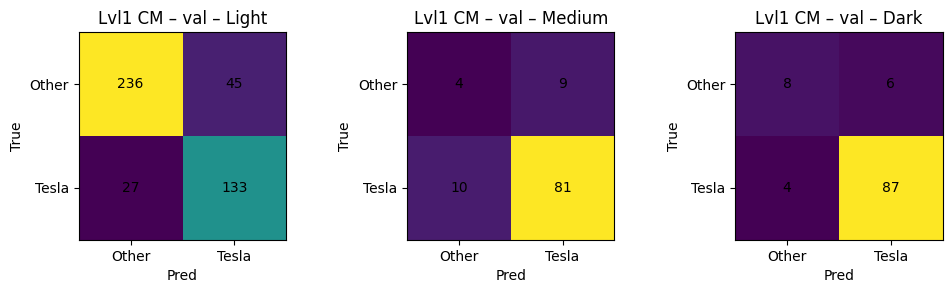

In [14]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, accuracy_score, balanced_accuracy_score,
    f1_score
)

def make_x_dataset(df):
    ds = make_dataset(df, training=False)   # deterministisk preprocess
    return ds.map(lambda x, y, sw: x)      # -> x

def predict_heads(model, df):
    x_ds = make_x_dataset(df)
    preds = model.predict(x_ds, verbose=0)
    p1 = preds["lvl1"].reshape(-1)                  # sigmoid
    p2 = preds["lvl2"]                              # softmax
    return p1, p2

def plot_cm_2x2(cm, title, save_path=None, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(3.6, 3.0))

    ax.imshow(cm, interpolation="nearest")
    ax.set_title(title)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Other", "Tesla"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Other", "Tesla"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    ax.set_xlabel("Pred")
    ax.set_ylabel("True")

    if ax is None and save_path:
        plt.tight_layout()
        plt.savefig(save_path, dpi=160)
        plt.show()

def eval_lvl1_by_lighting(model, df, lighting_col="lighting", threshold=0.5, lighting_order=("Light","Medium","Dark")):
    rows = []
    cms = {}

    # predikér én gang på hele df, så slicer vi per lighting (raskere)
    p1_all, _ = predict_heads(model, df)
    y_true_all = df["y_lvl1"].to_numpy().astype(int)
    y_pred_all = (p1_all >= threshold).astype(int)

    for light in lighting_order:
        dfi = df[df[lighting_col] == light]
        if len(dfi) == 0:
            continue

        idx = dfi.index.to_numpy()
        y_true = y_true_all[df.index.get_indexer(idx)]
        y_pred = y_pred_all[df.index.get_indexer(idx)]

        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])  # [[TN FP],[FN TP]]
        tn, fp, fn, tp = cm.ravel()

        tpr = tp / (tp + fn) if (tp + fn) else np.nan  # recall Tesla
        tnr = tn / (tn + fp) if (tn + fp) else np.nan  # recall Other

        row = {
            "lighting": light,
            "n_total": len(dfi),
            "n_other": int((y_true == 0).sum()),
            "n_tesla": int((y_true == 1).sum()),
            "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
            "TPR": tpr,
            "TNR": tnr,
            "lvl1_bal_acc": (tpr + tnr) / 2 if np.isfinite(tpr) and np.isfinite(tnr) else np.nan,
            "lvl1_acc": accuracy_score(y_true, y_pred),
            "lvl1_f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
            "lvl1_maj_acc": max(int((y_true == 0).sum()), int((y_true == 1).sum())) / len(dfi),
        }
        rows.append(row)
        cms[light] = cm

    return pd.DataFrame(rows), cms

# --- Kjør + lagre ---
out_dir = Path("results") / RUN_TAG / EVAL_SPLIT / "lvl1"
out_dir.mkdir(parents=True, exist_ok=True)

df_lvl1, cm_by_light = eval_lvl1_by_lighting(model, eval_df, threshold=0.5)
df_lvl1.to_csv(out_dir / "lvl1_metrics_by_lighting.csv", index=False, encoding="utf-8")
display(df_lvl1)

fig, axes = plt.subplots(1, 3, figsize=(10, 3.0))

for ax, light in zip(axes, ("Light","Medium","Dark")):
    if light in cm_by_light:
        plot_cm_2x2(cm_by_light[light], f"Lvl1 CM – {EVAL_SPLIT} – {light}", ax=ax)

fig.tight_layout()
fig.savefig(out_dir / "cm_lvl1_all.png", dpi=160)
plt.show()


,n_tesla,lvl2_acc,lvl2_bal_acc,lvl2_f1_macro,lvl2_maj_acc
0,342,0.432749,0.3285,0.364206,0.374269


,lighting,n_tesla,lvl2_acc,lvl2_bal_acc,lvl2_f1_macro
0,Light,160,0.500000,0.372010,0.410543
1,Medium,91,0.362637,0.170068,0.153362
2,Dark,91,0.384615,0.208532,0.204800


,class_id,class,support,precision,recall,f1
1,1,3 2024–nå,37,0.176471,0.081081,0.111111
0,0,3 2017–2023,52,0.314286,0.211538,0.252874
2,2,S 2012–2015,16,1.000000,0.250000,0.400000
3,3,S 2016–nå,19,0.833333,0.263158,0.400000
4,4,X,41,0.444444,0.390244,0.415584
6,6,Y 2025-nå,49,0.444444,0.408163,0.425532
5,5,Y 2020–2024,128,0.447236,0.695312,0.544343


,true,pred,rate,support_true
2,S 2012–2015,Y 2020–2024,0.625000,16
1,3 2024–nå,Y 2020–2024,0.621622,37
0,3 2017–2023,Y 2020–2024,0.538462,52
6,Y 2025-nå,Y 2020–2024,0.510204,49
3,S 2016–nå,Y 2020–2024,0.421053,19


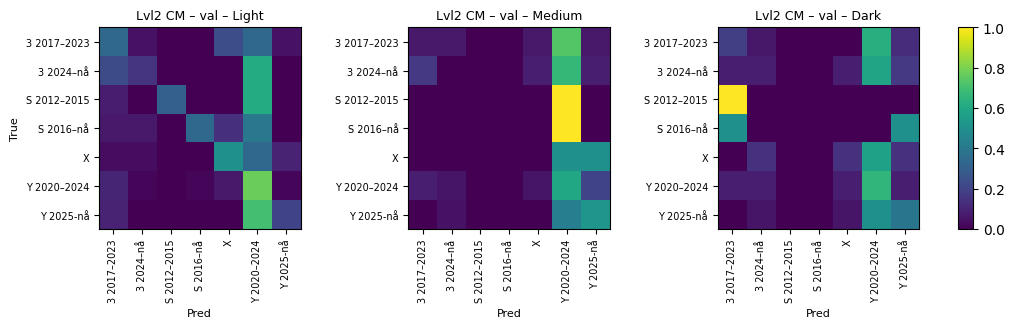

In [16]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, accuracy_score, balanced_accuracy_score,
    f1_score, precision_recall_fscore_support
)

def plot_cm_norm(cm_norm, labels, title, save_path=None, max_classes=30):
    plt.figure(figsize=(7.0, 6.0))
    plt.imshow(cm_norm, interpolation="nearest")
    plt.title(title)
    plt.xticks(range(len(labels)), labels, rotation=90)
    plt.yticks(range(len(labels)), labels)
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.xlabel("Pred")
    plt.ylabel("True")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=160)
    plt.show()

def eval_lvl2(model, df, lighting_col="lighting", lighting_order=("Light","Medium","Dark"), topn=8):
    # Tesla-only subset (ground truth gating)
    tesla_df = df[df["y_lvl1"].astype(int) == 1].copy()
    if tesla_df.empty:
        raise ValueError("Ingen Tesla-rader i eval_df – kan ikke evaluere lvl2.")

    # Predikér kun på Tesla-rader
    preds = model.predict(make_x_dataset(tesla_df, shuffle=False), verbose=0)
    p2 = preds["lvl2"]

    y_true = tesla_df["y_lvl2"].to_numpy().astype(int)
    y_pred = np.argmax(p2, axis=1).astype(int)

    counts = np.bincount(y_true, minlength=num_lvl2)
    lvl2_maj_acc = counts.max() / len(y_true)

    # Overall metrics
    overall = {
        "n_tesla": len(tesla_df),
        "lvl2_acc": accuracy_score(y_true, y_pred),
        "lvl2_bal_acc": balanced_accuracy_score(y_true, y_pred),
        "lvl2_f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "lvl2_maj_acc": lvl2_maj_acc,
    }
    df_overall = pd.DataFrame([overall])

    # Per lighting metrics (Tesla-only) + CM per lighting
    rows = []
    cm_norm_by_light = {}

    for light in lighting_order:
        mask = (tesla_df[lighting_col] == light).to_numpy()
        if mask.sum() == 0:
            continue

        y_t = y_true[mask]
        y_p = y_pred[mask]

        rows.append({
            "lighting": light,
            "n_tesla": int(mask.sum()),
            "lvl2_acc": accuracy_score(y_t, y_p),
            "lvl2_bal_acc": balanced_accuracy_score(y_t, y_p),
            "lvl2_f1_macro": f1_score(y_t, y_p, average="macro", zero_division=0),
        })

        cm_l = confusion_matrix(y_t, y_p, labels=list(range(num_lvl2)))
        with np.errstate(divide="ignore", invalid="ignore"):
            cm_l_norm = cm_l / cm_l.sum(axis=1, keepdims=True)
            cm_l_norm = np.nan_to_num(cm_l_norm)
        cm_norm_by_light[light] = cm_l_norm

    df_by_light = pd.DataFrame(rows)

    # Support per klasse x lyskategori (Tesla-only)
    support_tbl = (
        tesla_df.groupby(["lvl2", lighting_col]).size()
        .unstack(lighting_col, fill_value=0)
        .reindex(index=lvl2_classes, fill_value=0)
    )
    support_tbl["Total"] = support_tbl.sum(axis=1)
    support_tbl.loc["Total"] = support_tbl.sum(axis=0)

    # Per-klasse precision/recall/f1/support (overall Tesla-only)
    prec, rec, f1, sup = precision_recall_fscore_support(
        y_true, y_pred, labels=list(range(num_lvl2)), zero_division=0
    )
    df_per_class = pd.DataFrame({
        "class_id": range(num_lvl2),
        "class": lvl2_classes,
        "support": sup,
        "precision": prec,
        "recall": rec,
        "f1": f1,
    }).sort_values(["recall", "support"], ascending=[True, True])

    # Confusion matrix (normalisert per sann klasse)
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_lvl2)))
    with np.errstate(divide="ignore", invalid="ignore"):
        cm_norm = cm / cm.sum(axis=1, keepdims=True)
        cm_norm = np.nan_to_num(cm_norm)

    # Typiske forvekslinger (topp-5)
    confusions = []
    for i in range(num_lvl2):
        row = cm_norm[i].copy()
        row[i] = 0.0
        j = int(np.argmax(row))
        if row[j] > 0:
            confusions.append((lvl2_classes[i], lvl2_classes[j], float(row[j]), int(cm[i].sum())))
    df_confusions = (
        pd.DataFrame(confusions, columns=["true", "pred", "rate", "support_true"])
          .sort_values(["rate","support_true"], ascending=[False, False])
          .head(5)
    )

    return df_overall, df_by_light, support_tbl, df_per_class, cm_norm, df_confusions, cm_norm_by_light


# --- Kjør + lagre ---
out_dir = Path("results") / RUN_TAG / EVAL_SPLIT / "lvl2"
out_dir.mkdir(parents=True, exist_ok=True)

df_lvl2_overall, df_lvl2_by_light, support_tbl, df_lvl2_per_class, cm_norm, df_confusions, cm_norm_by_light = eval_lvl2(model, eval_df)

df_lvl2_overall.to_csv(out_dir / "lvl2_overall.csv", index=False, encoding="utf-8")
df_lvl2_by_light.to_csv(out_dir / "lvl2_metrics_by_lighting.csv", index=False, encoding="utf-8")
# #support_tbl.to_csv(out_dir / "lvl2_support_by_lighting.csv", encoding="utf-8")
df_lvl2_per_class.to_csv(out_dir / "lvl2_per_class_pr.csv", index=False, encoding="utf-8")
df_confusions.to_csv(out_dir / "lvl2_top_confusions.csv", index=False, encoding="utf-8")

display(df_lvl2_overall)
display(df_lvl2_by_light)
# display(support_tbl)
display(df_lvl2_per_class.head(10))    # “verste” recall først
display(df_confusions)

fig, axes = plt.subplots(1, 3, figsize=(10.2, 3.6))

for k, (ax, light) in enumerate(zip(axes, ("Light", "Medium", "Dark"))):
    if light not in cm_norm_by_light:
        ax.axis("off")
        continue

    im = ax.imshow(cm_norm_by_light[light], interpolation="nearest", vmin=0, vmax=1)
    ax.set_title(f"Lvl2 CM – {EVAL_SPLIT} – {light}", fontsize=9)

    ax.set_xticks(range(num_lvl2))
    ax.set_xticklabels(lvl2_classes, rotation=90, fontsize=7)
    ax.set_yticks(range(num_lvl2))
    ax.set_yticklabels(lvl2_classes, fontsize=7)

    ax.set_xlabel("Pred", fontsize=8)

    # Bare venstre plott får "True" for å unngå overlapp
    ax.set_ylabel("True" if k == 0 else "", fontsize=8)

# Litt mer luft mellom plottene + plass til colorbar
fig.subplots_adjust(left=0.06, right=0.90, top=0.86, bottom=0.30, wspace=0.30)

# Colorbar utenfor (robust)
cax = fig.add_axes([0.92, 0.30, 0.015, 0.56])
fig.colorbar(im, cax=cax)

fig.savefig(out_dir / "cm_lvl2_norm_by_lighting.png", dpi=160)
plt.show()